# 2. Phase transitions and the Ising model

The Ising model is probably the most studied model of 
ferromagnetism and phase transitions in general.
In the model, a set of spins $s_i= \pm 1$ reside
on the site of a $d$-dimensional lattice. The energy (or Hamiltonian) associated  with a configuration of spins $s_i$ is given by
\begin{equation}
\mathcal{H}= -J \sum_{\langle i,j \rangle} s_i s_j -H \sum_i s_i,
\end{equation}
where $J>1$ is the ferromagnetic coupling, favoring parallel
spins, and $H$ is the external magnetic field (in suitable units).
The first sum in the energy is restricted to
nearest-neighbor pairs. The Ising model can be solved exactly
in $d=2$ (for $H=0$) and displays a second-order phase transition
at a critical temperature $T_c$. Here we will study the model with Monte-Carlo simulations


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline

In [3]:
import matplotlib as mpl

mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

# 2.A Monte Carlo simulations

In this exercise, we focus on the case $J=1, H=0$, that is, a ferromagnetic system with no external field. Remember that the sum $\langle ij \rangle$ runs over neighbouring sites only. In our 2D lattice, each site has 4 neighbours. 

<img src="attachment:image.png" width="250"> 


We will work with **periodic boundary conditions**, so that all spins have 4 neighbours. 

<img src="attachment:image.png" width="250"> 


# The Metropolis algorithm
We will build a simple implementation of the **Metropolis** algorithm for the 2D Ising model. 

As a reminder, a single update of the Metropolis algorithm works as follows:

1. Pick a site $(i, j)$ at random.
2. Calculate the energy change $\Delta E$ that flipping the spin $s_{ij}$ would produce.
3. If $\Delta E <0$, flip the spin with probability $1$.
4. If $\Delta E >0$, flip the spin with probability $e^{-\beta \Delta E}$.

### Exercice 2.1
Write a function that, given an integer $N$, returns an $N \times N$ array whose elements are randomly picked from {-1, 1}. 

In [4]:
def create_initial_config(N=None):
    """
    Create the starting initial configuration.
    
    All elements are {-1, 1} with 50% prob.
    The lattice is a square of size N.
    
    Parameters
    ----------
    N : int
        The system size.

    Returns
    -------
    config : np.array, (N, N)
        A random {-1, 1} array of size (N, N).
    """
    config = np.random.choice([-1, 1], (N, N))
    return config

Let us create an initail configuration with our `create_inital_config_function`. A system size of $N=100$ will be enough.

In [5]:
config = create_initial_config(N=100)

To plot our system we can use `plt.imshow()`, as follows:

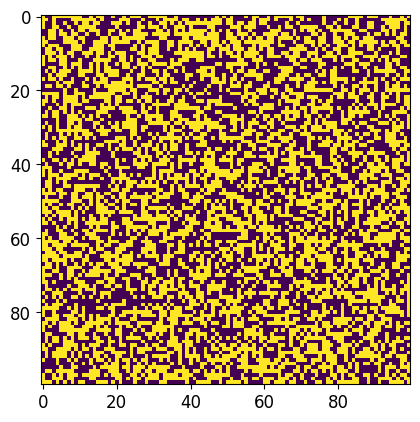

In [6]:
plt.imshow(config)

### Exercise 2.2
We will write our Metropolis update function. Given a site $(i, j)$, what is the change in energy $\Delta E$ that flipping $S(i, j)$ entails?
Recall that only 4 spins are connected to $(i, j)$, so you don't need to compute the energy of the whole system.

The change in energy $\Delta E$ shows whether the flipped spin aligns better with its neighbours ($\Delta E$ < 0) or worse ($\Delta E$ > 0 ).

### Exercise 2.3
Write a function called `metropolis_single_update()`.  
The **input** should be:

+ *config*, a lattice configuration as an (N, N) array.
+ *T*, the temperatue.

There is no need to return anything since in python, functions can modify its input, so we will be updating config *inplace*. But it is useful to return the energy change $\Delta E$ if one later wants to track the energy during simulations. To simplify things, we will use **periodic boundary conditions** (in python, the modulo operator is `%`).

In [7]:
def metropolis_single_update(config=None, T=None):
    '''
    Do a single Monte Carlo update using Metropolis algorithm.
    
    Parameters
    ----------
    config : np.array, (N, N)
        The current configuration.
    T : float
        The temperature.

    '''
    # make sure config is square
    N, M = config.shape
    assert N == M
    
    # choose random site
    i = np.random.randint(N)
    j = np.random.randint(N)
    s = config[i, j]
        
    # compute energy cost of flip
    # DeltaE is the possible energy cost
    # effDeltaE is the real energy cost (depending on whether we did the flip or not)
    DeltaE = 2 * s * sum([config[(i-1) % N, j], config[(i+1) % N, j], config[i, (j-1) % N], config[i, (j+1) % N]])
    effDeltaE = 0

    # case DeltaE < 0, flip the spin with prob 1 
    if DeltaE < 0:
        # flip the sping
        s *= -1
        # set effective DeltaE to DeltaE 
        effDeltaE = DeltaE
        
    # case DeltaE >= 0
    else:
        # flip the spin with certain probability
        if np.random.random() < np.exp(-DeltaE / T):
            # flip the sping
            s *= -1
            # set effective Delta E 
            effDeltaE = DeltaE
        
    # update configuration
    # notice there is no need to return the whole configuration, the function
    # will modify config _in_place_
    config[i, j] = s
    
    # but it is clever to return the effective DeltaE, since we have already computed it
    # notice that if we didn't flip the spin, the change in energy is 0
    return effDeltaE

## Visualizing the simulation on real time
To see if our Metropolis algorithm works, you might want to simulate systems at different temperatures, and observe how the configuration evolves trought time. To do this you need the `display` module. Below you will find an example of how to use it.

For the 2D Ising model, the **critical temperature** is known to be
$$
T_c = \frac{2}{\ln(1+\sqrt{2})} \simeq 2.2691853...
$$
(with $k_B=1$). Try executing the cell below at different values of the temperature, for different system size. 

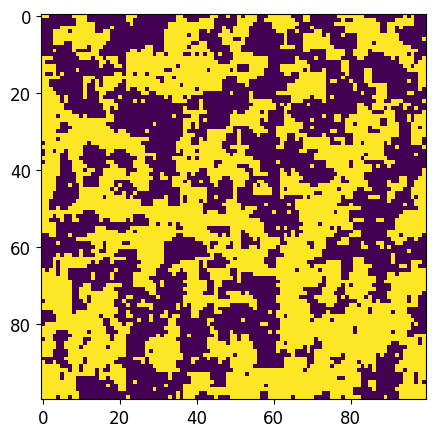

In [8]:
T_c = 2/np.log(1+np.sqrt(2))

# create initial random configuration
config = create_initial_config(N=100)

# set up figure, plot first frame
fig, ax = plt.subplots(1, 1, figsize=(6,5))
# draw the initial configuration,
# naming the plot "im".
im = ax.imshow(config)

for t in range(100000):
    # update the system
    DeltaE = metropolis_single_update(config, T=T_c)
    # replot every 1000 MC updates
    if t%1000==0:
        # update the data of the plot (not the whole figure!)
        im.set_data(config)
        # rerender
        display.display(plt.gcf())
        display.clear_output(wait=True)

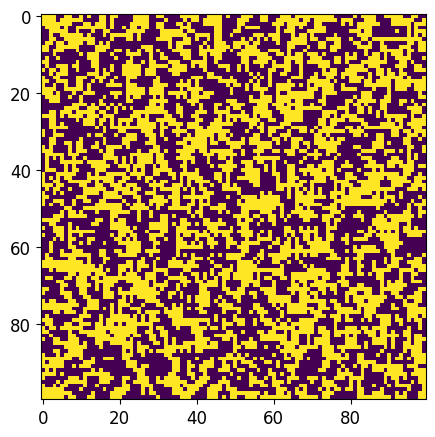

In [9]:
T_5 = 5

# create initial random configuration
config = create_initial_config(N=100)

# set up figure, plot first frame
fig, ax = plt.subplots(1, 1, figsize=(6,5))
# draw the initial configuration,
# naming the plot "im".
im = ax.imshow(config)

for t in range(100000):
    # update the system
    DeltaE = metropolis_single_update(config, T=T_5)
    # replot every 1000 MC updates
    if t%1000==0:
        # update the data of the plot (not the whole figure!)
        im.set_data(config)
        # rerender
        display.display(plt.gcf())
        display.clear_output(wait=True)

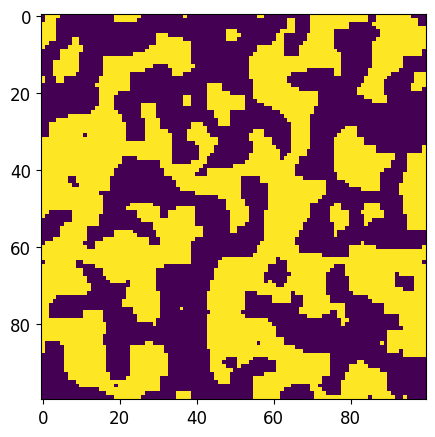

In [10]:
T_5 = 0.5

# create initial random configuration
config = create_initial_config(N=100)

# set up figure, plot first frame
fig, ax = plt.subplots(1, 1, figsize=(6,5))
# draw the initial configuration,
# naming the plot "im".
im = ax.imshow(config)

for t in range(100000):
    # update the system
    DeltaE = metropolis_single_update(config, T=T_5)
    # replot every 1000 MC updates
    if t%1000==0:
        # update the data of the plot (not the whole figure!)
        im.set_data(config)
        # rerender
        display.display(plt.gcf())
        display.clear_output(wait=True)

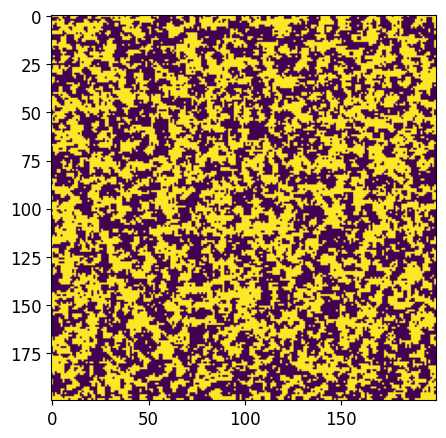

In [11]:
T_2 = 2

# create initial random configuration
config = create_initial_config(N=200)

# set up figure, plot first frame
fig, ax = plt.subplots(1, 1, figsize=(6,5))
# draw the initial configuration,
# naming the plot "im".
im = ax.imshow(config)

for t in range(100000):
    # update the system
    DeltaE = metropolis_single_update(config, T=T_2)
    # replot every 1000 MC updates
    if t%1000==0:
        # update the data of the plot (not the whole figure!)
        im.set_data(config)
        # rerender
        display.display(plt.gcf())
        display.clear_output(wait=True)

### Exercice 2.4
Write a function that computes the energy of a configuration, and another that tracks its evolution over time.

In [12]:
def get_energy(config):
    """
    Compute the energy of a configuration.
    
    The energy is defined as $E = -\sum_{(a, b)} S_a S_b$,    
    where the sum runs over pairs of adjacent spins.
    
    Parameters
    ----------
    config : np.array, (N, N)
        The system configuration.
        
        
    Returns
    -------
    E : float
        The energy of the configuration.
    """
    N = len(config)
    # list of pairs of adjacent sites as four-element tuples:
    # (i1, j1, i2, j2) represents two adjacent sites located
    # at (i1, j1) and (i2, j2)
    horizontal_edges = [
        (i, j , (i + 1) % N, j)
        for i in range(N) for j in range(N)
    ]
    vertical_edges = [
        (i, j, i, (j + 1) % N)
        for i in range(N) for j in range(N)
    ]
    # summing lists in python concatenates them
    # [1, 2, 3] + [4, 5] = [1, 2, 3, 4, 5]
    edges = horizontal_edges + vertical_edges
    E = 0
    for i1, j1, i2, j2 in edges:
        E -= config[i1, j1] * config[i2, j2]
    
    return E

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/var/folders/91/v0zrf7r10db595g6bmjsfn440000gn/T/ipykernel_6369/735519336.py:5: SyntaxWarning: invalid escape sequence '\s'
  The energy is defined as $E = -\sum_{(a, b)} S_a S_b$,


In [ ]:
def get_energy_evolution(N=20, T=T_c, n_updates=50000):
    """
    Compute the energy evolution of a 2D Ising instance.
    
    Parameters
    ----------
    N : int
        The system size.
    T : float
        The temperature.
    n_updates : int
        Number of Metropolis updates.
        
    Returns
    -------
    Es : np.array, (n_updates, )
    """
    Es = np.zeros(n_updates)
    effDeltaE = 0
    config = create_initial_config(N=N)
    E = get_energy(config)
    for i in range(n_updates):
        Es[i] = E
        effDeltaE = metropolis_single_update(config, T)
        E += effDeltaE

    return Es

### Exercise 2.5
Compute the energy of your system during a long simulation, and plot it as a function of time. **Tip** Use logarithmic x-axis!

In [14]:
T_c = 2/np.log(1+np.sqrt(2))
n_updates = 1000000
N = 20
energy_evolution = get_energy_evolution(N=N, T=T_c, n_updates=n_updates)

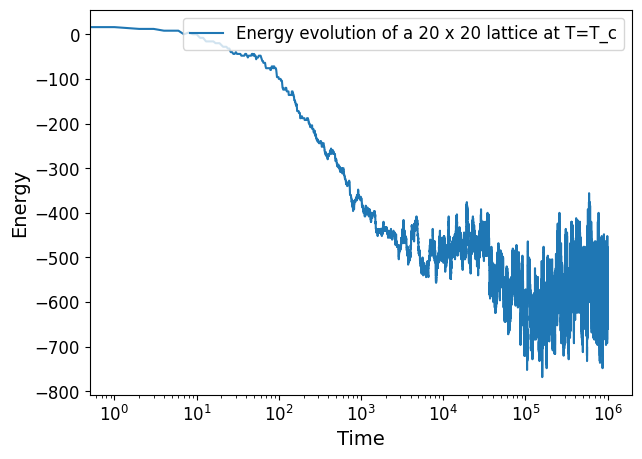

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.semilogx(np.arange(n_updates), energy_evolution, label=f"Energy evolution of a {N} x {N} lattice at T=T_c")

ax.set_xlabel("Time")
ax.set_ylabel("Energy")
ax.legend()

### Exercise 2.6
Can you distinguish two qualitatively different periods? What do they correspond to?

There are two visible periods - one of more or less stable decline of energy and a period when the energy oscillates. The period of decline corresponds to the equilibration of the system, it starts with high energy - so the configuration is chaotic. The oscialltion period refers to the equivilibrium state of the system - the energy is mostly stable but in this simulation the algorithm keeps changing the spins. 

## Magnetization
We will now compute the magnetization $M$ as a function of the temperature $T$.

### Exercise 2.7
Write a function that computes the magnetization of a 2D Ising system after certain equilibration period.

In [16]:
def calculate_magnetization(system_size=None, temperature=None, equilibration_time=None):
    """
    Calculate the magnetization of a 2D Ising model.
    
    Parameters
    ----------
    system_size : int
        The lattice size.
    temperature : float
        The simulation temperature.
    equilibration_time : int
        Number of sweeps before measuring M.
        
    """
    # instantiate model
    config = create_initial_config(N=system_size)
    # equilibrate
    for i in range(equilibration_time):
        for _ in range(system_size**2):
            metropolis_single_update(config, temperature)
    # compute magnetization
    m = np.sum(config)/system_size**2
    return m


### Exercise 2.8
+ Compute the magnetization for a system of size $N=64$, for different values of $T\in[1.5, 3.5]$.
+ Remember to choose wisely the equilibration time!
+ Plot $|M|$ as a function of $T$, and mark the critical temperature in your plot using the `plt.axvline()` function.

In [17]:
# define range of temperatures
temperatures = np.linspace(1.5, 3.5, num=50)
# system size
system_size = 64
# equilibration time
equilibration_time = 1500

# loop over temperatures, compute magnetizations
magnetizations = []
for temperature in temperatures:
    magnetization = calculate_magnetization(system_size=system_size, temperature=temperature, equilibration_time=equilibration_time)
    magnetizations.append(magnetization)

Text(0, 0.5, 'Magnetisation')

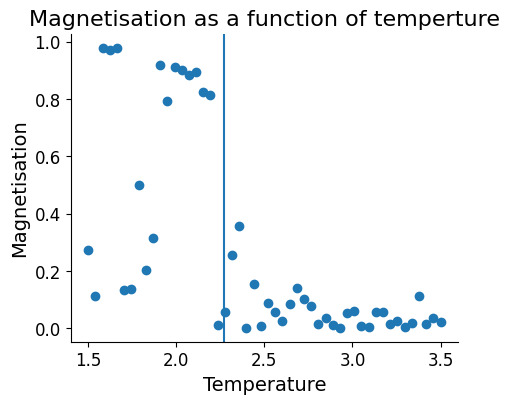

In [18]:
# define critical temperature
T_c = 2/np.log(1+np.sqrt(2))

mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

fig, ax = plt.subplots(1, 1, figsize=(5,4))
ax.scatter(
    temperatures, np.abs(magnetizations),
    # style keywords
    # edgecolors=..., color=..., s=...
)
ax.axvline(
    T_c,
    # style keywords
    # c=..., lw=..., ls=...
)
ax.set_title("Magnetisation as a function of temperture")
ax.set_xlabel("Temperature")
ax.set_ylabel("Magnetisation")

# Finding clusters
Given an Ising configuration, we define a cluster of spins as a set of neighbouring spins of the same sign surrounded by spins of the opposite sign.

<img src="attachment:image.png" width="600">

### Exercise 2.9
The formal definition of cluster is very clear, but in practice, how do you find (*efficiently* if possible) all clusters for a given configuration? We need to assign a **unique cluster label** to each spin. The cluster label could be anything (a color, a letter, a number...), it just needs to be the same for all spins that belong to the same cluster. For simplicity, we will use integers.

Think about an algorithm that assigns unique cluster labels to spins. Explain your algorithm in simple words / steps / pseudocode.

Remember:
+ Clusters can trespass (periodic) boundary conditions
+ Both `+1`'s and `-1`'s can form clusters!

*Your answer here*

### Exercise 2.10
Write a function that, given a configuration array `config`, returns another array `labels` where each cluster has a different label.

<img src="attachment:image.png" width="600">

Remember:
+ Clusters can trespass (periodic) boundary conditions
+ Both `+1`'s and `-1`'s can form clusters!


In [19]:
def get_labels(config):
    """
    Get unique cluster labels.
    
    Parameters
    ----------
    config : np.array, (N, N)
        Configuration of the system in {-1, 1} notation
    Returns
    -------
    labels : np.array, (N, N)
        Labels that identify the clusters
    """
    N = config.shape[0]
    labels = np.zeros((N, N), dtype=int)
    current_label = 0
    
    for i in range(N):
        for j in range(N):
            # If this spin isn't labeled yet, start a new cluster
            if labels[i, j] == 0:
                current_label += 1
                spin_value = config[i, j]
                
                # Use a stack/queue to find all connected spins of the same value
                stack = [(i, j)]
                labels[i, j] = current_label
                
                while stack:
                    r, c = stack.pop()
                    
                    # Check 4 neighbors with Periodic Boundary Conditions
                    for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                        ni, nj = (r + dr) % N, (c + dc) % N
                        
                        # If neighbor is same spin and not labeled
                        if config[ni, nj] == spin_value and labels[ni, nj] == 0:
                            labels[ni, nj] = current_label
                            stack.append((ni, nj))
                            
    return labels

### Test your function
To help you **test** your function, I have prepared some test data, so that we can all try our algorithms using the same input.

In [20]:
config_test_0 = np.array([[ 1,  1,  1],
                          [-1, -1,  1],
                          [-1, -1,  1]])

In [21]:
config_test_1 = np.array([[ 1, -1, -1,  1, -1,  1],
                          [-1, -1, -1,  1, -1,  1],
                          [-1,  1, -1, -1, -1,  1],
                          [-1,  1, -1,  1,  1,  1],
                          [-1,  1, -1, -1,  1, -1],
                          [-1, -1, -1,  1,  1,  1]])

In [22]:
config_test_2 = np.array([[ 1, -1,  1,  1, -1,  1, -1,  1,  1,  1],
                          [-1, -1, -1,  1,  1, -1, -1, -1,  1, -1],
                          [ 1, -1,  1, -1, -1, -1,  1,  1, -1,  1],
                          [ 1, -1,  1,  1,  1, -1,  1, -1,  1, -1],
                          [-1, -1,  1,  1, -1,  1, -1,  1,  1,  1],
                          [ 1, -1, -1, -1,  1, -1,  1,  1, -1,  1],
                          [-1,  1, -1,  1,  1, -1, -1, -1,  1,  1],
                          [-1, -1, -1, -1,  1,  1, -1, -1, -1,  1],
                          [ 1,  1, -1, -1,  1, -1,  1,  1,  1,  1],
                          [ 1,  1, -1, -1, -1,  1,  1,  1,  1, -1]])


Execute the following cell to make sure your function works correctly. The left column will show the test configurations, and the right column will show the clusters your function found, with different clusters colored in different colors

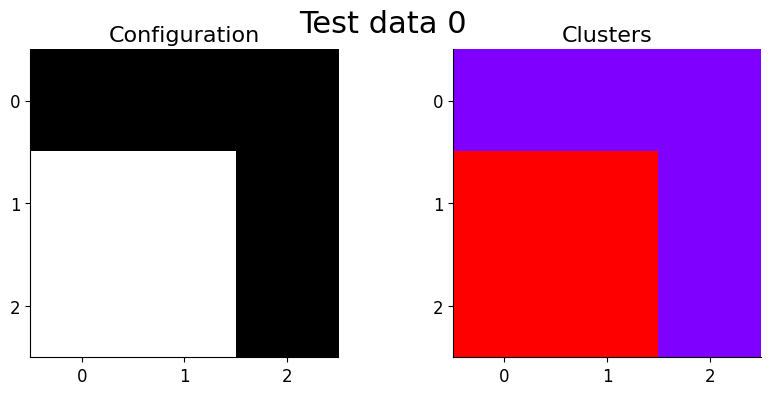

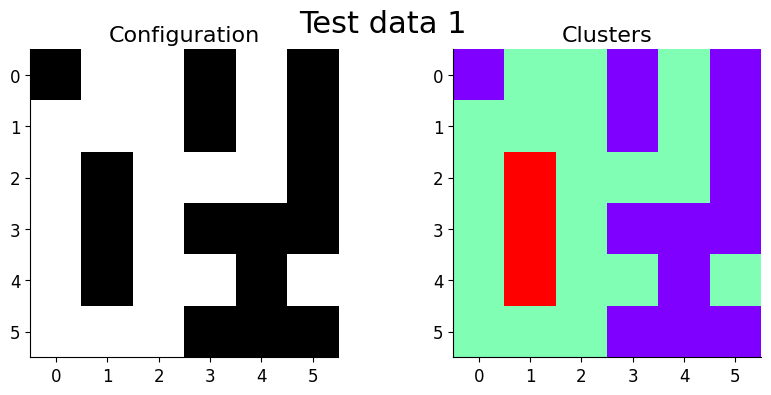

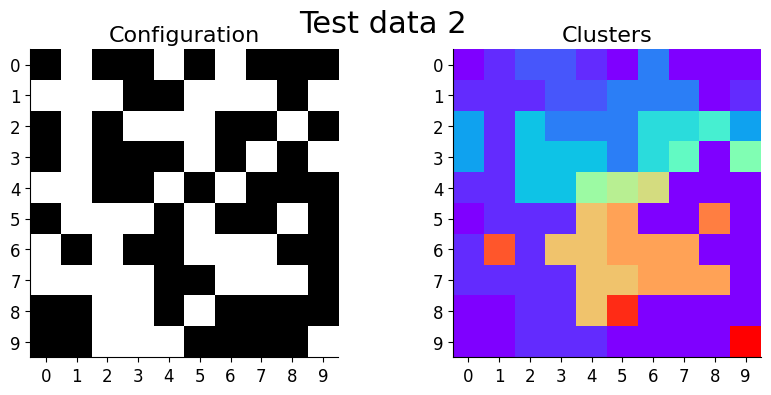

In [23]:
for i, config in enumerate([config_test_0, config_test_1, config_test_2]):
    labels = get_labels(config)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
    ax1.set_xticks(range(len(config)))
    ax1.set_yticks(range(len(config)))
    ax2.set_xticks(range(len(config)))
    ax2.set_yticks(range(len(config)))
    ax1.set_title("Configuration")
    ax2.set_title("Clusters")
    ax1.imshow(config, cmap="Greys")
    ax2.imshow(labels, cmap="rainbow")
    
    fig.suptitle(f"Test data {i}", fontsize=22)

If your function doesn't work, you might want to use this cell to inspect your results

<Axes: >

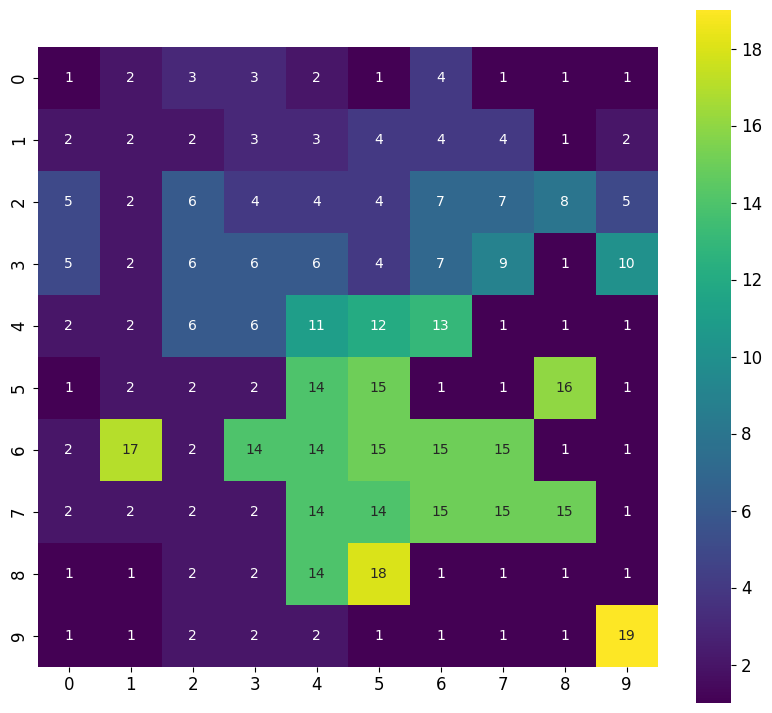

In [24]:
import seaborn as sns
fig, ax = plt.subplots(1, 1, figsize=(10, 9))
ax.set_aspect(1)
sns.heatmap(labels, annot=True, ax=ax, cmap="viridis")

### Measuring cluster sizes
Use your `get_labels()` function to find clusters in a large Ising model, say $N=500$. You can use your own Ising implementation. If you use Sethna's code, remember that he uses $s \in \{0, 1\}$ spins!

In [25]:
config = create_initial_config(N=500)
labels = get_labels(config)

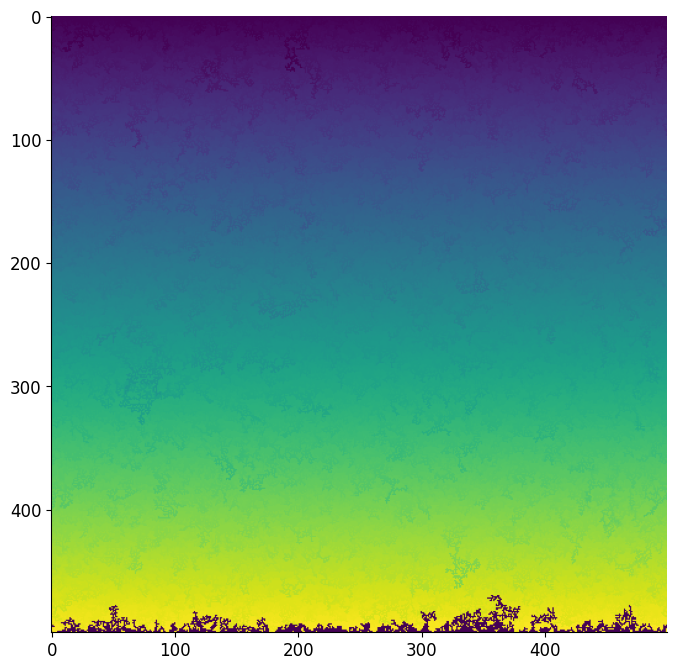

In [26]:
plt.figure(figsize=(10, 8))
plt.imshow(labels)

### Exercise 2.11
Find an efficient way to measure cluster sizes. Remind that all you care about is the distribution of cluster sizes, their location does not matter. You might want to use the `.reshape()` method of a numpy array, and the `Counter` class from the `collections` package.

In [27]:
def get_sizes(labels):
    values, sizes = np.unique(labels, return_counts=True)
    return sizes

### Exercise 2.12
For $T >> T_c$, spins are essentially uncorrelated. What is the distribution of cluster sizes you expect to find in this case? **Hint** Think about the 1D case assuming totally uncorrelated spins.

Since the spins are uncorrelated, each spin has a probability of 0.5, thus it will result in a lot of clusters of small size and the count of bigger clusters would decrease very fast, since the probability of, say 50 spins aligning in a row is very low: $0.5^{50}$.



### Exercice 2.13
Do a simulation at very high temperature and measure the cluster size distribution. Plot your results in log-log scale. Do your results agree with your previous answer?

They do agree with my intuition, the plot shows that the distribution creates a downward curve which goes down very fast at larger cluster sizes in log scale, which suggests that the distribution follows an exponential decay.

In [28]:
config = create_initial_config(N=500)
T = 100
n_updates = 10e6
for _ in range(int(n_updates)):
    metropolis_single_update(config, T=T)
    
labels = get_labels(config)
sizes = get_sizes(labels)

(np.int64(1), np.int64(600))

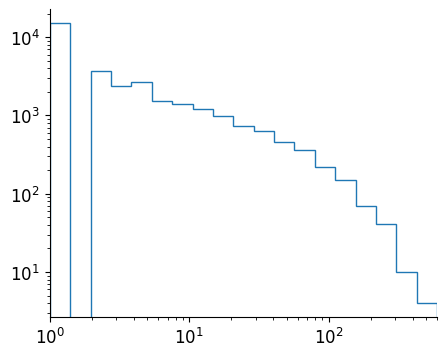

In [29]:
# use logarithmic bins and logarithmic axes!
bins = np.geomspace(min(sizes), max(sizes), num=20)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(sizes, bins=bins, histtype="step")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(min(sizes), max(sizes))

### Exercise 2.14

At $T_c$, the distribution of cluster sizes is known to be a power law with exponent close to $\alpha \simeq 2$.

$$
P(s) \propto s^{-\alpha}
$$

Do a simulation at $T=T_c$ and compare the resulting cluster size distribution with that obtained at $T>>T_c$.

In [30]:
# do simulation
T_c = 2/np.log(1+np.sqrt(2))

config = create_initial_config(N=500)
n_updates = 10e6
for _ in range(int(n_updates)):
    metropolis_single_update(config, T=T_c)
    
labels = get_labels(config)
sizes = get_sizes(labels)

(np.int64(1), np.int64(102840))

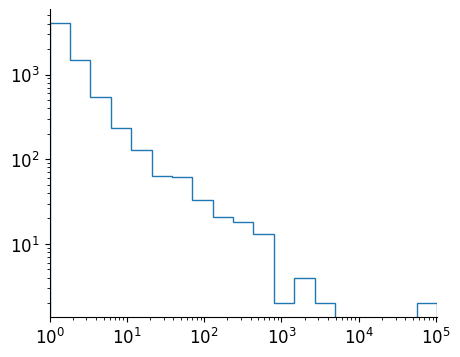

In [31]:
# plot results
bins = np.geomspace(min(sizes), max(sizes), num=20)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(sizes, bins=bins, histtype="step")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(min(sizes), max(sizes))

The first plot shows a downward curve, whereas the second one shows more of a line, therefore the second plot for simulation at the critical temperature displays the power law distribution of the cluster sizes, while the high temperature simulation shows an exponential decay.

# 2. B Domain corsening dynamics
In the part above we concentrated on the study of the equilibrium properties of the Ising model. We will now study how the model reaches equilibrium when it is "quenched" from the disordered phase into the ordered phase.

Start the sample from a random spin configuration,  then run briefly at H = 0 and $T \gg T_c$. Now set $T\ll T_c$ and observe the dynamics describing how the domain patterns changes with time. 

    measuring on the screen by eye,
    by writing a subroutine to measure correlation functions and finding the half-maximum, or
     (valid only at low temperature), 

find the typical size L(t) of the red and white domains, and graph it versus time. What power law do we expect it to grow with? Does it grow as expected? When do finite-size effects start changing things? 



### Exercise 2.15 
Plot snapshots of the configurations at different times to show the dynamics.


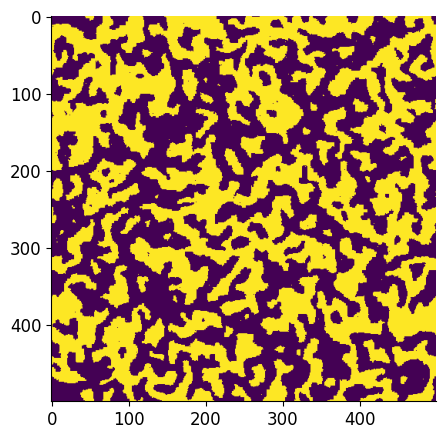

In [ ]:
n_updates = 10000
T_h = 10
N=500
config = create_initial_config(N=N)

for _ in range(n_updates):
    metropolis_single_update(config, T=T_h)
fig, ax = plt.subplots(1, 1, figsize=(6,5))
im = ax.imshow(config)

T_l = 1
n_updates = 10e6
for i in range(int(n_updates)):
    metropolis_single_update(config, T=T_l)
    if i%N**2==0:
        # update the data of the plot
        im.set_data(config)
        display.display(plt.gcf())
        display.clear_output(wait=True)

### Exercise 2.16 
Compute the cluster size distribution and the average cluster size at different times, and graph them versus time (use a log-log scale). For a very large system, it is expected that $\langle L(t) \rangle \sim t^{1/2}$. If the curve is noisy you can average over different statistically identical realizations of the same process. 


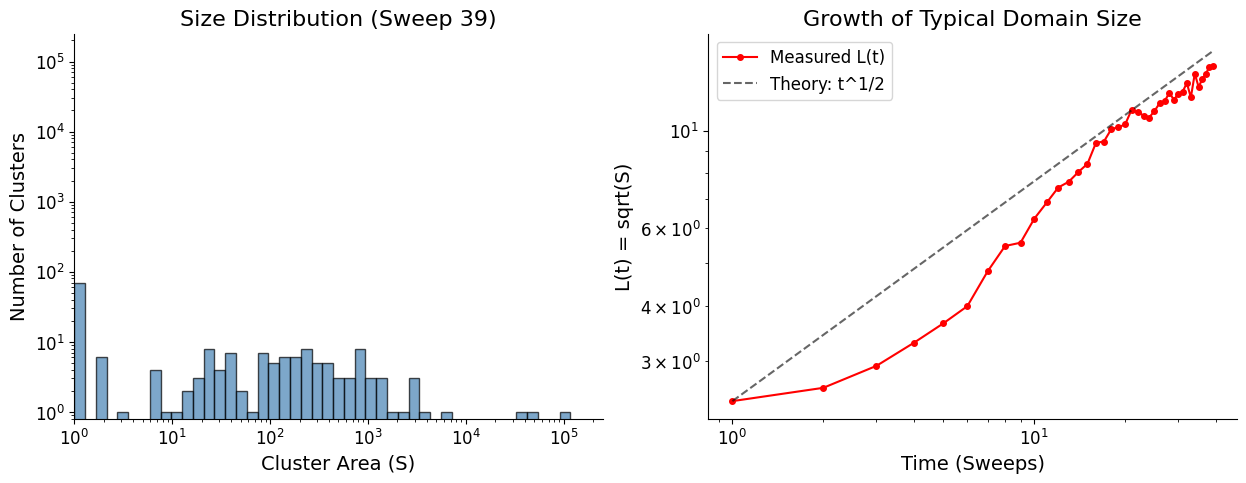

In [35]:
N = 500
T_low = 1.0
n_updates = int(1e7)  
plot_interval = N**2      

sweep_counts = []
L_typical_values = []

# Initialize Configuration
config = create_initial_config(N=N)

fig, (ax_dist, ax_growth) = plt.subplots(1, 2, figsize=(15, 5))

for i in range(n_updates):
    metropolis_single_update(config, T=T_low)
    
    if i % plot_interval == 0 and i > 0:
        # Get Cluster Sizes
        labels = get_labels(config)
        _, counts = np.unique(labels, return_counts=True)
        
        # Calculate Typical Size L(t) = Mean of sqrt(S)
        current_L_typical = np.mean(np.sqrt(counts))
        
        current_sweep = i / plot_interval
        sweep_counts.append(current_sweep)
        L_typical_values.append(current_L_typical)
        
        # Update Plots
        ax_dist.clear()
        ax_growth.clear()
        
        # Left Plot: Cluster Size Distribution (Log-Log)
        # We plot the 'Area' S here to see the distribution change
        bins = np.logspace(0, np.log10(N*N), 50)
        ax_dist.hist(counts, bins=bins, density=False, alpha=0.7, color='steelblue', edgecolor='black')
        ax_dist.set_xscale('log')
        ax_dist.set_yscale('log')
        ax_dist.set_xlim(1, N*N)
        ax_dist.set_ylim(0.8, N*N) # Fixed Y to see the small clusters disappear
        ax_dist.set_title(f"Size Distribution (Sweep {int(current_sweep)})")
        ax_dist.set_xlabel("Cluster Area (S)")
        ax_dist.set_ylabel("Number of Clusters")
        
        # Right Plot: Average Length L(t) vs Time (Log-Log)
        ax_growth.loglog(sweep_counts, L_typical_values, 'r-o', markersize=4, label='Measured L(t)')
        
        # Add the Theoretical t^0.5 reference line
        if len(sweep_counts) > 1:
            # We start the theory line from our first measured point
            theory = [L_typical_values[0] * (t/sweep_counts[0])**0.5 for t in sweep_counts]
            ax_growth.plot(sweep_counts, theory, 'k--', alpha=0.6, label='Theory: t^1/2')
        
        ax_growth.set_title("Growth of Typical Domain Size")
        ax_growth.set_xlabel("Time (Sweeps)")
        ax_growth.set_ylabel("L(t) = sqrt(S)")
        ax_growth.legend()

        display.display(plt.gcf())
        display.clear_output(wait=True)

### Exercise 2.17

Use the energy as a measure of the total length of the surface between spin up and spin down regions. Plot this length as a function of time in a log-log plot.

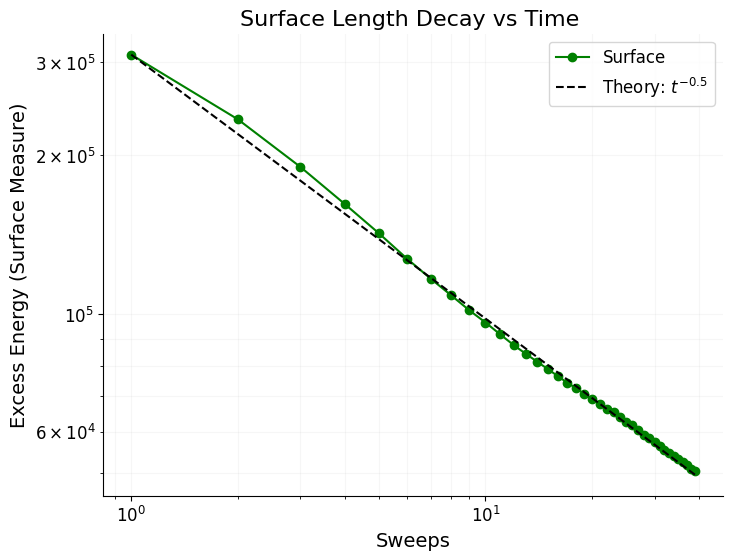

In [39]:
N = 500
T_l = 1.0
n_updates = int(1e7)
sweep = N**2

sweep_counts = []
energy_values = []

# Start from the random/high-T config
config = create_initial_config(N=N)

# Run the simulation
for i in range(n_updates):
    # Use your defined metropolis function
    metropolis_single_update(config, T=T_l)
    
    if i % sweep == 0 and i > 0:
        current_E = get_energy(config)
        
        # Calculate 'Surface'
        # In the Ising model, the ground state energy is -2 * J * N^2 (for 2D)
        # Surface Length is proportional to E_current - E_ground
        ground_state = -2.0 * (N * N) 
        excess_energy = current_E - ground_state
        
        sweep_counts.append(i / sweep)
        energy_values.append(excess_energy)

# Final Plot
plt.figure(figsize=(8, 6))
plt.loglog(sweep_counts, energy_values, 'g-o', label='Surface')

# Theoretical line for t^-0.5
if len(sweep_counts) > 1:
    theory_down = [energy_values[0] * (t/sweep_counts[0])**-0.5 for t in sweep_counts]
    plt.plot(sweep_counts, theory_down, 'k--', label='Theory: $t^{-0.5}$')

plt.title("Surface Length Decay vs Time ")
plt.xlabel("Sweeps")
plt.ylabel("Excess Energy (Surface Measure)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.show()

# 2.C Model for segregation

We now study here the Schilling model for urban segregation introduced in 

Schelling, Thomas C. (1971). "Dynamic models of segregation". The Journal of Mathematical Sociology. Informa UK Limited. 1 (2): 143–186. doi:10.1080/0022250x.1971.9989794
(see also https://arxiv.org/abs/1104.1971 for review of the different variants of the model). 

Here we will consider a square lattice (LxL) representing a city whose cells can be occupied by individuals belonging two different groups A and B or be empty. We can define a variable $\sigma_i$ which is equal to 1 if the individual in i belongs to the group A, to -1 if it belongs to B and 0 if the site is empty. 

The rule of the model is as follows: each individual is happy if the neighborhood is prevalently composed by members of the same group. We define the neighborhood of the site i by the 8 adjacent lattice sites
ad shown in the figure:

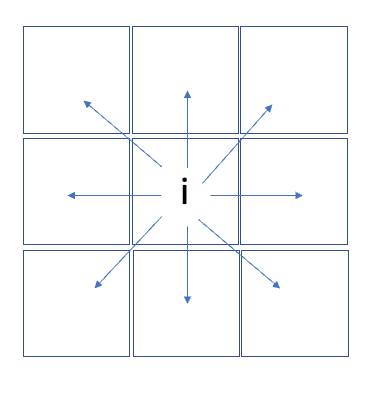

Individuals are satisfied if the fraction of neighbors belonging to their own group is larger than a threshold $B_0$. If they are not satisfied they will move to another location.  


### Exercise 2.18

Write a code to perform a Monte Carlo simulation of the Schelling model using a random update algorithm. At each time step: 
- 1 pick a site at random
- 2 check the fraction of neighbors B belonging to the same group ad the individual in i.
- 3 if $B<B_0$ pick at random an empty site in the latteice and "move" the individual there.
- 4 go back to 1

In [51]:
def schelling_iteration(grid, threshold_B0):
    grid_size = grid.shape[0]
    # 1. Pick a site at random
    row, col = np.random.randint(0, grid_size, size=2)
    individual = grid[row, col]
    
    if individual == 0: return # Skip empty
    
    # 2. Check fraction B of same-group neighbors
    same, total = 0, 0
    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            if dr == 0 and dc == 0: continue
            neighbor = grid[(row + dr) % grid_size, (col + dc) % grid_size]
            if neighbor != 0:
                total += 1
                if neighbor == individual: same += 1
    
    fraction_B = same / total if total > 0 else 1.0
    
    # 3. If unhappy, move to a random empty site
    if fraction_B < threshold_B0:
        empty_indices = np.argwhere(grid == 0)
        new_row, new_col = empty_indices[np.random.randint(len(empty_indices))]
        grid[new_row, new_col] = individual
        grid[row, col] = 0

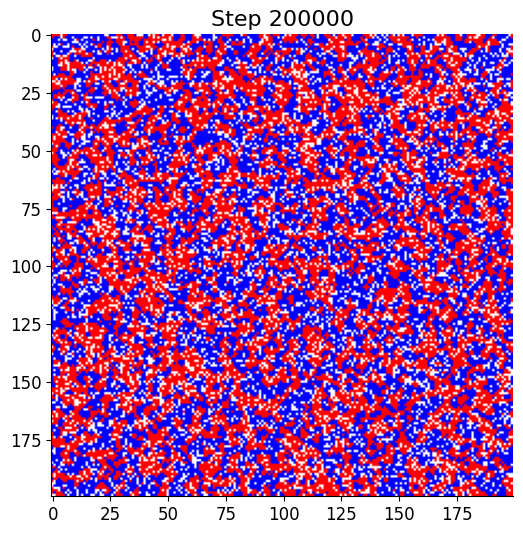

In [ ]:
N = 200
total_steps = 200000
B0 = 0.375 #[0.125, 0.25, 0.375, 0.5, 0.625, 0.750, 0.875, 1.0] possible values
city = np.random.choice([1, -1, 0], size=(N, N), p=[0.4, 0.4, 0.2])

fig, ax = plt.subplots(figsize=(6,6))
img = ax.imshow(city, cmap='bwr')

for step in range(total_steps+1):
    schelling_iteration(city, B0)
    
    if step % 2000 == 0:
        img.set_data(city)
        ax.set_title(f"Step {step}")
        display.display(plt.gcf())
        display.clear_output(wait=True)

### Exercise 2.19
Study the dynamics of the Schelling model as a function of the parameter $B_0$. You can set the initial condition at random with 20% of sites empty and 40% each occupied by the two groups. 

- run the simulation for some time and plot some representative snapshots of the configurations at different times.

- compute the average cluster size as a function of $B_0$ in the long time limit. Is there segregation or mixing?

- study how the cluster size grows with time. Does it scale as $t^{1/2}$ as in the Ising model?


In [57]:
def get_average_cluster_size(grid):
    labels = get_labels(grid)
    unique, counts = np.unique(labels, return_counts=True)
    # We exclude the '0' label if your get_labels treats empty space as a cluster
    return np.mean(counts)

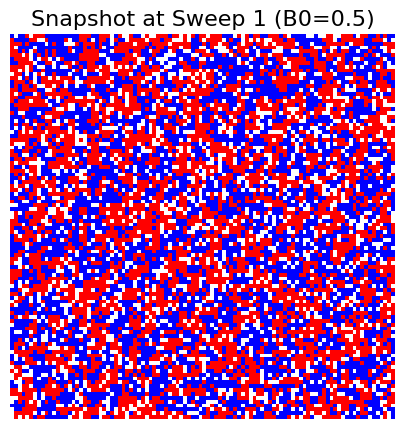

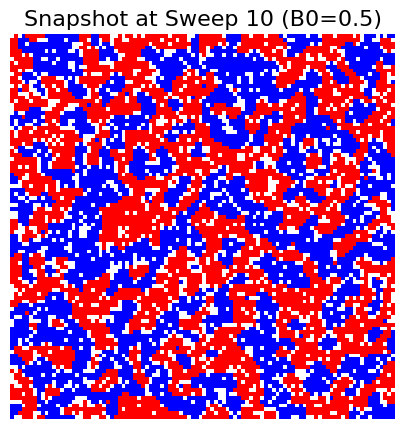

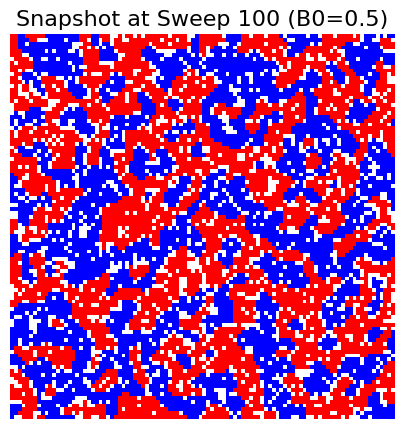

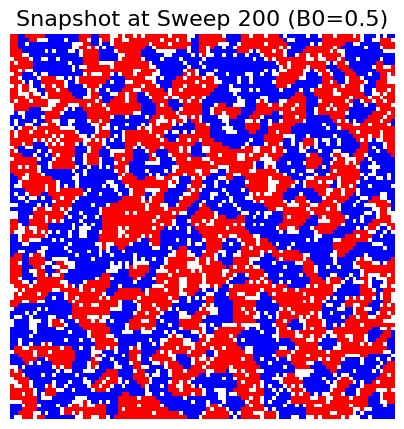

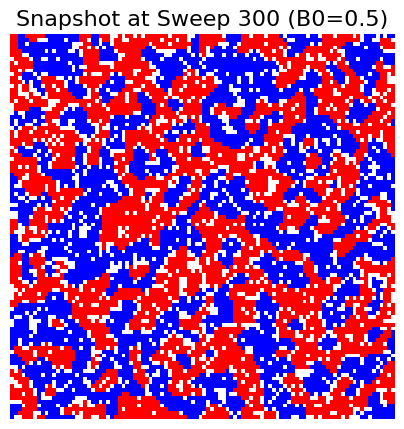

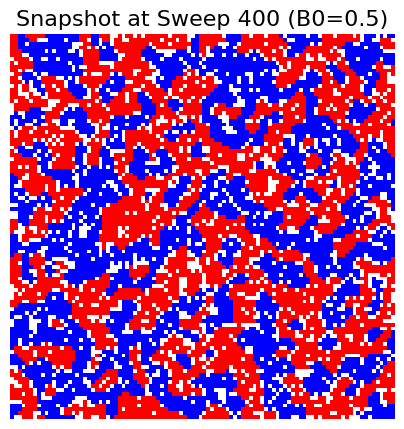

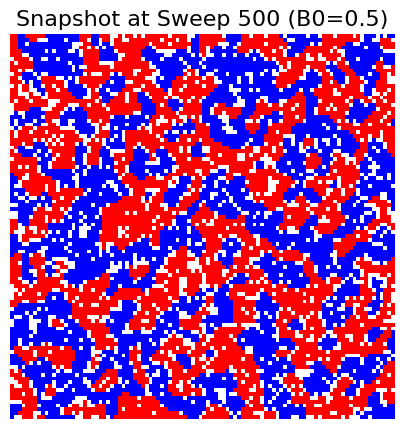

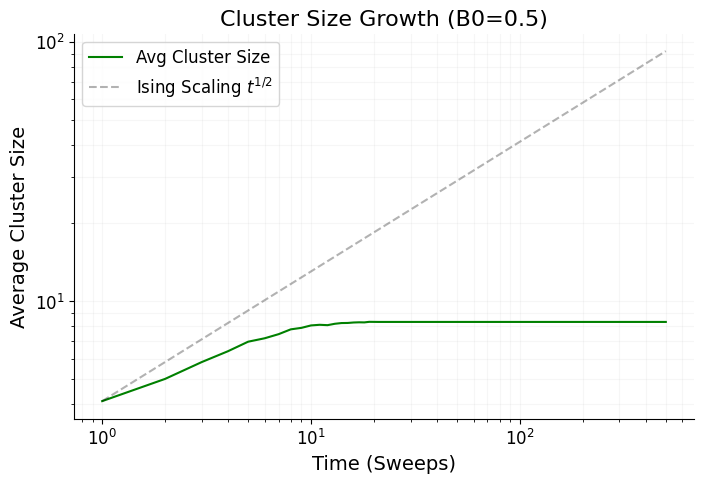

In [ ]:
N = 100
B0 = 0.5
total_sweeps = 500
snapshot_times = [1, 10, 100, 200, 300, 400, 500]

city = np.random.choice([1, -1, 0], size=(N, N), p=[0.4, 0.4, 0.2])

times, sizes = [], []

# SIMULATION
for sweep in range(1, total_sweeps + 1):
    # Run one full sweep
    for _ in range(N**2):
        schelling_iteration(city, B0)
    
    # Measure using your functions
    current_size = get_average_cluster_size(city)
    times.append(sweep)
    sizes.append(current_size)

    # SNAPSHOTS
    if sweep in snapshot_times:
        plt.figure(figsize=(5, 5))
        plt.imshow(city, cmap='bwr')
        plt.title(f"Snapshot at Sweep {sweep} (B0={B0})")
        plt.axis('off')
        plt.show()

plt.figure(figsize=(8, 5))
plt.loglog(times, sizes, 'g-', label='Avg Cluster Size')
# Add the t^1/2 reference for the scaling question
plt.loglog(times, [sizes[0]*t**0.5 for t in times], 'k--', alpha=0.3, label='Scaling $t^{1/2}$')

plt.title(f"Cluster Size Growth (B0={B0})")
plt.xlabel("Time (Sweeps)")
plt.ylabel("Average Cluster Size")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.show()